# High-Vol-Only 3-Asset Volatility Harvester

This notebook runs a simplified volatility-harvesting strategy that is **only active during periods of high volatility** (no trend logic).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
def tearsheet_stats(
    returns: pd.Series,
    *,
    turnover: pd.Series | None = None,
    active: pd.Series | None = None,
    periods_per_year: int = 252,
) -> dict:
    returns = returns.dropna()
    eq = (1.0 + returns).cumprod()

    ann_ret = returns.mean() * periods_per_year
    ann_vol = returns.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    years = len(eq) / periods_per_year
    cagr = eq.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan

    dd = eq / eq.cummax() - 1.0
    max_dd = float(dd.min())

    out = {
        "CAGR": f"{cagr:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "Annual Vol": f"{ann_vol:.2%}",
        "Max Drawdown": f"{max_dd:.2%}",
    }
    if turnover is not None:
        out["Avg Daily Turnover"] = f"{float(turnover.mean()):.3f}"
    if active is not None:
        out["Active %"] = f"{float(active.mean()):.1%}"
    return out


In [3]:
def backtest_vol_harvest_3asset_highvol_only(
    prices: pd.DataFrame,
    *,
    tickers: tuple[str, str, str] = ("SPY", "TLT", "GLD"),
    start: str | None = None,
    end: str | None = None,
    rebalance: str = "W-FRI",             # "W-FRI" or "M"
    vol_lookback: int = 60,               # for risk-parity weights + vol targeting
    target_vol: float = 0.10,
    leverage_cap: float = 2.0,

    # High-vol gate
    high_vol_anchor: str = "SPY",
    high_vol_window: int = 63,
    high_vol_threshold: float = 0.20,     # annualized realized vol

    # NEW: drift-based rebalance trigger
    drift_threshold: float | None = 0.08, # L1 weight drift; None disables

    baseline_when_inactive: tuple[float, float, float] = (0.0, 1.0, 0.0),
    cost_bps: float = 1.0,
    periods_per_year: int = 252,
) -> dict:
    """
    High-vol-only volatility harvesting with drift-based rebalancing.
    """
    cols = list(tickers)

    # -----------------------------
    # Prices / returns
    # -----------------------------
    px = prices.copy()
    px.index = pd.to_datetime(px.index).tz_localize(None)
    if start:
        px = px.loc[px.index >= pd.to_datetime(start)]
    if end:
        px = px.loc[px.index <= pd.to_datetime(end)]
    px = px[cols].dropna()

    r = px.pct_change().dropna()
    idx = r.index
    if len(px) < max(vol_lookback, high_vol_window) + 10:
        raise ValueError("Not enough history for requested windows.")

    # -----------------------------
    # High-vol activation signal
    # -----------------------------
    rv = (
        r[high_vol_anchor]
        .rolling(high_vol_window)
        .std(ddof=1) * np.sqrt(periods_per_year)
    )
    active = (rv >= high_vol_threshold).astype(float).reindex(idx).fillna(0.0)

    # -----------------------------
    # Risk-parity weights (shifted)
    # -----------------------------
    vol = r.rolling(vol_lookback).std(ddof=1).shift(1)
    inv = 1.0 / vol.replace(0.0, np.nan)
    w_rp = inv.div(inv.sum(axis=1), axis=0)
    w_rp = w_rp.reindex(idx).fillna(pd.Series([1/3, 1/3, 1/3], index=cols)).ffill()

    # -----------------------------
    # Baseline weights (inactive)
    # -----------------------------
    w_base = pd.DataFrame(
        np.tile(np.array(baseline_when_inactive, dtype=float), (len(idx), 1)),
        index=idx,
        columns=cols,
    )
    w_base = w_base.div(w_base.sum(axis=1), axis=0)

    # -----------------------------
    # Target weights
    # -----------------------------
    cond = (active.values > 0.5).reshape(-1, 1)
    w_target = pd.DataFrame(
        np.where(cond, w_rp.values, w_base.values),
        index=idx,
        columns=cols,
    )

    # -----------------------------
    # Rebalance dates
    # -----------------------------
    rb_dates = px.resample(rebalance).last().index.intersection(idx)
    if len(rb_dates) < 2:
        raise ValueError("Not enough rebalance points.")
    rb_set = set(rb_dates)

    # -----------------------------
    # Constant-mix engine (calendar + drift)
    # -----------------------------
    w_applied = pd.DataFrame(index=idx, columns=cols, dtype=float)
    turnover = pd.Series(0.0, index=idx)
    gross_port = pd.Series(0.0, index=idx)

    vals = pd.Series(w_target.iloc[0].values, index=cols, dtype=float)
    pv = 1.0

    for i, dt in enumerate(idx):
        if i == 0:
            w_applied.loc[dt] = vals.values
            continue

        # evolve sleeves
        vals = vals * (1.0 + r.loc[dt, cols])
        pv_now = float(vals.sum())

        w_now = (vals / pv_now).values
        w_tgt = w_target.loc[dt, cols].values

        # drift (L1 distance)
        drift = float(np.abs(w_now - w_tgt).sum())

        # rebalance condition
        need_reb = (
            (dt in rb_set and active.loc[dt] > 0.5)
            or (drift_threshold is not None and drift >= drift_threshold)
        )

        if need_reb:
            to = drift
            cost = (cost_bps / 1e4) * to * pv_now
            pv_after = max(pv_now - cost, 0.0)
            vals = pd.Series(pv_after * w_tgt, index=cols)
            pv_new = pv_after
            turnover.loc[dt] = to
        else:
            pv_new = pv_now

        gross_port.loc[dt] = (pv_new / pv) - 1.0
        pv = pv_new
        w_applied.loc[dt] = (vals / pv).values if pv > 0 else w_tgt

    # -----------------------------
    # Portfolio vol targeting
    # -----------------------------
    realized = gross_port.rolling(vol_lookback).std(ddof=1) * np.sqrt(periods_per_year)
    lev = (target_vol / realized).clip(0.0, leverage_cap).shift(1).fillna(1.0)

    net = (gross_port * lev).rename("returns").dropna()
    equity = (1.0 + net).cumprod().rename("equity")

    return {
        "returns": net,
        "equity": equity,
        "weights": w_applied.reindex(net.index),
        "turnover": turnover.reindex(net.index),
        "leverage": lev.reindex(net.index),
        "signals": {
            "active": active.reindex(net.index),
            "realized_vol": rv.reindex(net.index),
        },
        "Params": {
            "tickers": tickers,
            "rebalance": rebalance,
            "drift_threshold": drift_threshold,
            "vol_lookback": vol_lookback,
            "target_vol": target_vol,
            "high_vol_window": high_vol_window,
            "high_vol_threshold": high_vol_threshold,
            "baseline_when_inactive": baseline_when_inactive,
            "cost_bps": cost_bps,
        },
    }


In [4]:
# --- Configure / load prices ---
TICKERS = ("JEPQ", "SGOV", "SGOL")

px = (
    yf.download(list(TICKERS), start="2010-01-01", auto_adjust=True, progress=False)["Close"]
    .dropna()
)

res = backtest_vol_harvest_3asset_highvol_only(
    prices=px,
    tickers=TICKERS,
    start="2012-01-01",
    rebalance="W-FRI",
    vol_lookback=40,
    target_vol=0.08,
    leverage_cap=2.0,
    high_vol_anchor="SGOL",
    high_vol_window=63,
    high_vol_threshold=0.22,
    baseline_when_inactive=(0.0, 1.0, 0.0),  # park in TLT
    cost_bps=1.0,
)

pd.Series(tearsheet_stats(
    res["returns"],
    turnover=res["turnover"],
    active=res["signals"]["active"],
))


CAGR                   9.14%
Sharpe                 16.69
Annual Vol             0.52%
Max Drawdown          -0.26%
Avg Daily Turnover     0.000
Active %               11.2%
dtype: object

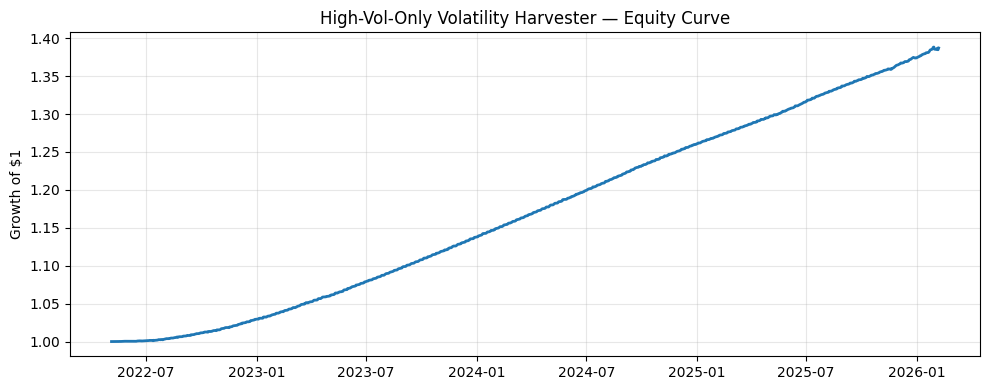

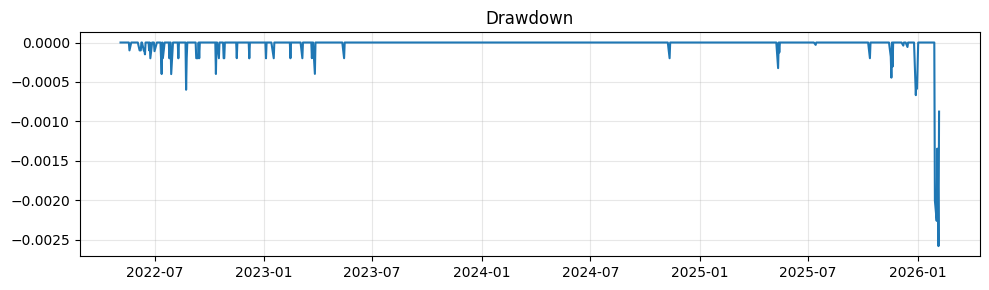

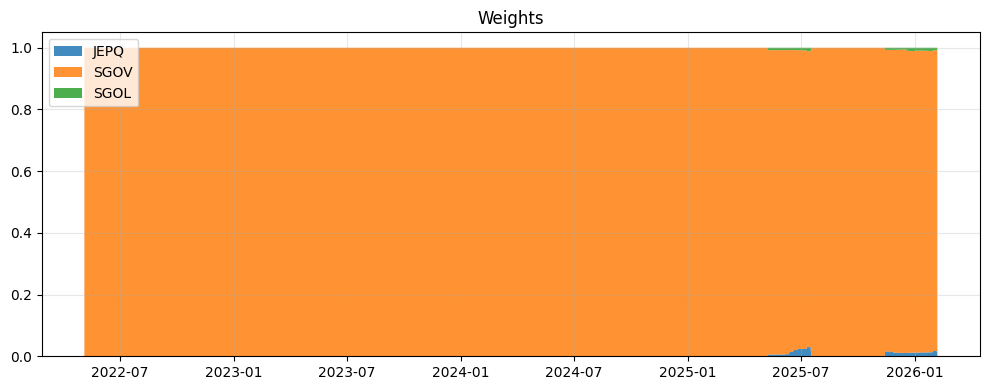

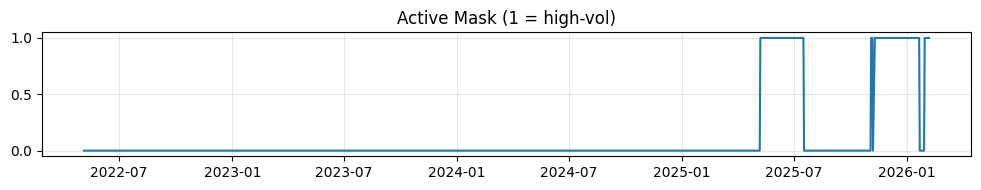

In [5]:
# --- Plots ---
equity = res["equity"]
returns = res["returns"]
weights = res["weights"]
active = res["signals"]["active"]

drawdown = equity / equity.cummax() - 1.0

plt.figure(figsize=(10,4))
plt.plot(equity.index, equity.values, linewidth=2)
plt.title("High-Vol-Only Volatility Harvester — Equity Curve")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(drawdown.index, drawdown.values, linewidth=1.5)
plt.title("Drawdown")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.stackplot(weights.index, weights.T.values, labels=weights.columns, alpha=0.85)
plt.title("Weights")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,2))
plt.plot(active.index, active.values, linewidth=1.5)
plt.title("Active Mask (1 = high-vol)")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


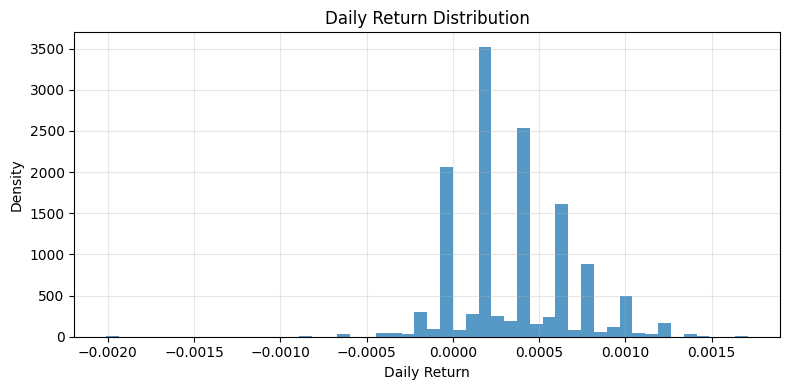

In [6]:
plt.figure(figsize=(8,4))
plt.hist(returns, bins=50, density=True, alpha=0.75)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
equity.to_csv("../../portfolio/data/volatility-triple-harvester.csv")